### load

In [1]:
import numpy as np
import pandas as pd
import polars as pl
from polars import selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler, FunctionTransformer, OrdinalEncoder, OneHotEncoder, TargetEncoder, Binarizer
from sklearn.compose import ColumnTransformer, make_column_selector, TransformedTargetRegressor
from sklearn.model_selection import train_test_split,cross_validate,KFold,GridSearchCV
from sklearn.metrics import root_mean_squared_log_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, MissingIndicator
%matplotlib inline

from add_features import add_modified_features

In [2]:
train = pl.read_csv('../data/train.csv',infer_schema_length=None,null_values='NA')
test = pl.read_csv('../data/test.csv',infer_schema_length=None,null_values = 'NA')

print(train.shape, test.shape)

(1460, 81) (1459, 80)


In [3]:
drop = [
    'Id',
    '2ndFlrSF',
    '1stFlrSF',
]

X = train.select(cs.exclude(drop,'SalePrice'))
y = train['SalePrice']

X_test = test.select(cs.exclude(drop,'SalePrice'))
X.glimpse()

Rows: 1460
Columns: 77
$ MSSubClass    <i64> 60, 20, 60, 70, 60, 50, 20, 60, 50, 190
$ MSZoning      <str> 'RL', 'RL', 'RL', 'RL', 'RL', 'RL', 'RL', 'RL', 'RM', 'RL'
$ LotFrontage   <i64> 65, 80, 68, 60, 84, 85, 75, null, 51, 50
$ LotArea       <i64> 8450, 9600, 11250, 9550, 14260, 14115, 10084, 10382, 6120, 7420
$ Street        <str> 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave'
$ Alley         <str> null, null, null, null, null, null, null, null, null, null
$ LotShape      <str> 'Reg', 'Reg', 'IR1', 'IR1', 'IR1', 'IR1', 'Reg', 'IR1', 'Reg', 'Reg'
$ LandContour   <str> 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl'
$ Utilities     <str> 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub'
$ LotConfig     <str> 'Inside', 'FR2', 'Inside', 'Corner', 'FR2', 'Inside', 'Inside', 'Corner', 'Inside', 'Corner'
$ LandSlope     <str> 'Gtl', 'Gtl', 'Gtl', 'Gtl', 'Gtl', 'Gtl', 'Gtl', 'Gtl', 'Gtl', 

### explore

In [4]:
train.describe()

statistic,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,…,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
str,f64,f64,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,str,str,str,str,str,f64,str,str,str,str,str,str,str,f64,str,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,str,str,f64
"""count""",1460.0,1460.0,"""1460""",1201.0,1460.0,"""1460""","""91""","""1460""","""1460""","""1460""","""1460""","""1460""","""1460""","""1460""","""1460""","""1460""","""1460""",1460.0,1460.0,1460.0,1460.0,"""1460""","""1460""","""1460""","""1460""","""1452""",1452.0,"""1460""","""1460""","""1460""","""1423""","""1423""","""1422""","""1423""",1460.0,"""1422""",…,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,"""1460""",1460.0,"""1460""",1460.0,"""770""","""1379""",1379.0,"""1379""",1460.0,1460.0,"""1379""","""1379""","""1460""",1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,"""7""","""281""","""54""",1460.0,1460.0,1460.0,"""1460""","""1460""",1460.0
"""null_count""",0.0,0.0,"""0""",259.0,0.0,"""0""","""1369""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""8""",8.0,"""0""","""0""","""0""","""37""","""37""","""38""","""37""",0.0,"""38""",…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,"""0""",0.0,"""690""","""81""",81.0,"""81""",0.0,0.0,"""81""","""81""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""1453""","""1179""","""1406""",0.0,0.0,0.0,"""0""","""0""",0.0
"""mean""",730.5,56.89726,null,70.049958,10516.828082,null,null,null,null,null,null,null,null,null,null,null,null,6.099315,5.575342,1971.267808,1984.865753,null,null,null,null,null,103.685262,null,null,null,null,null,null,null,443.639726,null,…,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,null,6.517808,null,0.613014,null,null,1978.506164,null,1.767123,472.980137,null,null,null,94.244521,46.660274,21.95411,3.409589,15.060959,2.758904,null,null,null,43.489041,6.321918,2007.815753,null,null,180921.19589
"""std""",421.610009,42.300571,null,24.284752,9981.264932,null,null,null,null,null,null,null,null,null,null,null,null,1.382997,1.112799,30.202904,20.645407,null,null,null,null,null,181.066207,null,null,null,null,null,null,null,456.098091,null,…,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,null,1.625393,null,0.644666,null,null,24.689725,null,0.747315,213.804841,null,null,null,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,null,null,null,496.123024,2.703626,1.328095,null,null,79442.502883
"""min""",1.0,20.0,"""C (all)""",21.0,1300.0,"""Grvl""","""Grvl""","""IR1""","""Bnk""","""AllPub""","""Corner""","""Gtl""","""Blmngtn""","""Artery""","""Artery""","""1Fam""","""1.5Fin""",1.0,1.0,1872.0,1950.0,"""Flat""","""ClyTile""","""AsbShng""","""AsbShng""","""BrkCmn""",0.0,"""Ex""","""Ex""","""BrkTil""","""Ex""","""Fa""","""Av""","""ALQ""",0.0,"""ALQ""",…,0.0,0.0,334.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Ex""",2.0,"""Maj1""",0.0,"""Ex""","""2Types""",1900.0,"""Fin""",0.0,0.0,"""Ex""","""Ex""","""N""",0.0,0.0,0.0,0.0,0.0,0.0,"""Ex""","""GdPrv""","""Gar2""",0.0,1.0,2006.0,"""COD""","""Abnorml""",34900.0
"""25%""",366.0,20.0,null,59.0,7558.0,null,null,null,

In [5]:
nulls = train.select(cs.numeric()).to_pandas().isna().sum()
nulls[nulls > 0]

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

### col-prep mapping

In [6]:
map_label = {
    'Street': {'Pave':1,'Grvl':0},
    'CentralAir': {'Y':1, 'N':0},
}

eq_val_label = {
    'Heating': 'GasA',
    'PavedDrive': 'Y',
}

is_na_label = [
    'Alley',
    'PoolQC',
    'Fence',
    'MiscFeature',
]

is_zero_label = [
    'LowQualFinSF',
    'BsmtFinSF2',
    'PoolArea',
    'BsmtHalfBath',
    'ScreenPorch',
    '3SsnPorch',
    'MiscVal',
]


# 欠損 = データ不備（最頻値で補完）
ordinal_encoded_data_error = {
    'KitchenQual':['Po','Fa','TA','Gd','Ex'],
    'Functional':['Typ','Min1', 'Min2', 'Mod', 'Maj1', 'Maj2', 'Sev', 'Sal'],
}

# 欠損 = 該当設備なし（"Missing"で補完）
ordinal_encoded_no_feature = {
    'FireplaceQu':['Missing', 'Po','Fa','TA','Gd','Ex'],
    'GarageQual':['Missing', 'Po','Fa','TA','Gd','Ex'],
    'GarageCond': ['Missing', 'Po','Fa','TA','Gd','Ex'],
}

one_hot_encoded = [  # 最頻値で補完
    'MSZoning',
    'LotShape',
    'LandContour',
    'Utilities',
    'LotConfig',
    'LandSlope',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'ExterQual',
    'ExterCond',
    'Foundation',
    'HeatingQC',
    'SaleType',
    'SaleCondition',
    'Electrical',
    'MasVnrType',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'GarageType',
    'GarageFinish',
]

target_encoded = [
    'MSSubClass',
    'Neighborhood',
]

log_standardized = [ # 中央値で補完
    'LotFrontage',
    'LotArea',
    'YearBuilt',
    'GrLivArea',
    'BsmtUnfSF',
    'TotalBsmtSF',
    'BsmtFinSF1',
    'MasVnrArea',
    'EnclosedPorch',
    'HalfBath',
    'OpenPorchSF',
    'WoodDeckSF',
    # 追加
    'TotalFlrSF',
    'BsmtAboveRatio',
    'LivLotRatio',
]

standardized = [ # 中央値で補完
    'OverallQual',
    'OverallCond',
    'BsmtFullBath',
    'FullBath',
    'BedroomAbvGr',
    'KitchenAbvGr',
    'TotRmsAbvGrd',
    'Fireplaces',
    'GarageYrBlt',
    'GarageCars',
    'GarageArea',
    'MoSold',
    'YrSold',
    'OverallScore',
    'BathScore',
    # 'building_age_at_sale',
    'IsOverAllGE9',
    'SoldMay2July',
    'SoldAfterRehman'
]

### pipeline

In [7]:
# Target-Pipeline
log_standardize_y = Pipeline([
    ("log", FunctionTransformer(np.log1p, inverse_func=np.expm1, check_inverse=False)),
    ("scale", StandardScaler())
])

# Features Pipeline
log_standardize = Pipeline([
    ("log", FunctionTransformer(np.log1p, inverse_func=np.expm1, check_inverse=False, feature_names_out="one-to-one")),
    ("scale", StandardScaler())
])

# map_label: 明示的な値->コードのマッピング（Street, CentralAir）
map_label_pipeline = Pipeline([
    ("ordinal", OrdinalEncoder(categories=[
        sorted(mapping, key=mapping.get) for mapping in map_label.values()
    ])),
    ("scale", StandardScaler()),
])

# eq_val_label: 指定値と一致するかどうかの2値化（Heating, PavedDrive）
eq_val_label_pipeline = Pipeline([
    ("eq", FunctionTransformer(
        lambda X, values=list(eq_val_label.values()): (np.asarray(X) == values).astype(int),
        feature_names_out="one-to-one",
    )),
    ("scale", StandardScaler()),
])

# is_na_label: 欠損（＝その設備なし）を示す2値フラグ
is_na_label_pipeline = Pipeline([
    ("indicator", MissingIndicator(features="all", missing_values=None)),
    ("scale", StandardScaler()),
])

# is_zero_label: 0でないかを示す2値フラグ
is_zero_label_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value=0)),
    ("binarize", Binarizer(threshold=0)),
    ("scale", StandardScaler()),
])

# ordinal_encoded_data_error: 欠損はデータ不備のため最頻値で補完してから順序エンコード
# ※ Functionalのみ Typ=0 を基準に悪化するほど負の値になるよう符号を反転する
ordinal_data_error_sign = np.array([-1 if col == 'Functional' else 1 for col in ordinal_encoded_data_error])

ordinal_encoded_data_error_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent", missing_values=None)),
    ("ordinal", OrdinalEncoder(categories=list(ordinal_encoded_data_error.values()))),
    ("sign", FunctionTransformer(
        lambda X: np.asarray(X) * ordinal_data_error_sign,
        feature_names_out="one-to-one",
    )),
])

# ordinal_encoded_no_feature: 欠損は該当設備なしを意味するので"Missing"で補完してから順序エンコード
ordinal_encoded_no_feature_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Missing", missing_values=None)),
    ("ordinal", OrdinalEncoder(categories=list(ordinal_encoded_no_feature.values()))),
])

# one_hot_encoded: 最頻値で補完してからOne-Hotエンコード
one_hot_encoded_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent", missing_values=None)),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# target_encoded: 最頻値で補完してからターゲットエンコード
target_encoded_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent", missing_values=None)),
    ("target", TargetEncoder()),
    ("scale", StandardScaler())
])

# log_standardized: 中央値で補完してから対数変換+標準化
log_standardized_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("log_standard", log_standardize),
])

# standardized: 中央値で補完してから標準化
standardized_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

In [8]:
preprocessor = ColumnTransformer([
    ("map_label", map_label_pipeline, list(map_label.keys())),
    ("eq_val_label", eq_val_label_pipeline, list(eq_val_label.keys())),
    ("is_na_label", is_na_label_pipeline, is_na_label),
    ("is_zero_label", is_zero_label_pipeline, is_zero_label),
    ("ordinal_encoded_data_error", ordinal_encoded_data_error_pipeline, list(ordinal_encoded_data_error)),
    ("ordinal_encoded_no_feature", ordinal_encoded_no_feature_pipeline, list(ordinal_encoded_no_feature)),
    ("one_hot_encoded", one_hot_encoded_pipeline, one_hot_encoded),
    ("target_encoded", target_encoded_pipeline, target_encoded),
    ("log_standardized", log_standardized_pipeline, log_standardized),
    ("standardized", standardized_pipeline, standardized),
], remainder="drop")


### add modified feature

In [9]:
X = add_modified_features(X)
X_test = add_modified_features(X_test)

X_train, X_va, y_train, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### cross validation

Fold 1: train RMSLE = 0.1045 / valid RMSLE = 0.1261
Fold 2: train RMSLE = 0.1041 / valid RMSLE = 0.1294
Fold 3: train RMSLE = 0.0970 / valid RMSLE = 0.1593
Fold 4: train RMSLE = 0.1090 / valid RMSLE = 0.1121
Fold 5: train RMSLE = 0.1101 / valid RMSLE = 0.1049
CV平均: train 0.1049 / valid 0.1264
最終スコア(test RMSLE): 0.1303


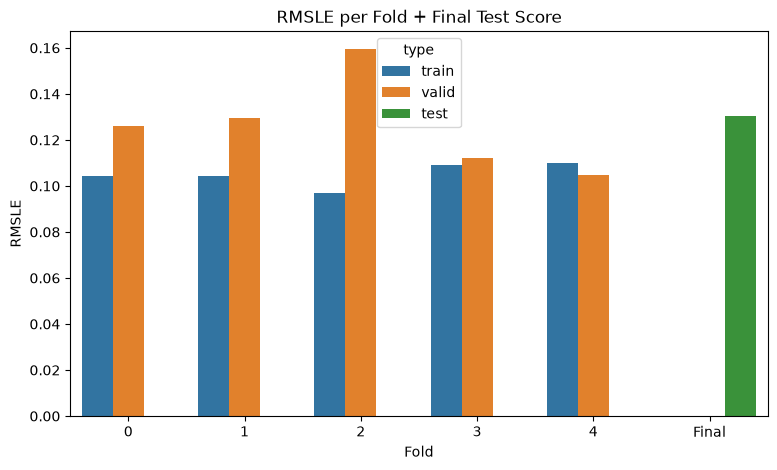

In [10]:
base_model = Pipeline([
    ("prep", preprocessor),
    ("ridge", Ridge(alpha=10))
])
model = TransformedTargetRegressor(
    regressor=base_model,
    transformer=log_standardize_y,
    check_inverse=False
)

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)
result = cross_validate(
    model, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_log_error",
    return_train_score=True,
)

# スコア表示
train_scores = -result["train_score"]
valid_scores = -result["test_score"]

for i, (tr, va) in enumerate(zip(train_scores, valid_scores), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores.mean():.4f} / valid {valid_scores.mean():.4f}")

model.fit(X_train, y_train)
test_score = root_mean_squared_log_error(y_va, model.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score:.4f}")

# スコアグラフ
df = pl.DataFrame({
    "Fold": [str(i) for i in range(folds)] * 2 + ["Final"],
    "RMSLE": list(train_scores) + list(valid_scores) + [test_score],
    "type": ["train"] * folds + ["valid"] * folds + ["test"],
})

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Fold", y="RMSLE", hue="type")
plt.title("RMSLE per Fold + Final Test Score")
plt.show()


### grid search

In [11]:
param_grid = {
    "regressor__ridge__alpha": [0.01, 0.1, 1, 3, 10, 30, 100, 300, 1000],
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_log_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV RMSLE: {-grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
test_score_gs = root_mean_squared_log_error(y_va, best_model.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_gs:.4f}")

# alphaごとのCVスコア一覧
cv_results = pd.DataFrame(grid_search.cv_results_)[
    ["param_regressor__ridge__alpha", "mean_test_score", "std_test_score"]
].assign(
    mean_test_RMSLE=lambda df: -df["mean_test_score"]
).sort_values("param_regressor__ridge__alpha")
cv_results


Best params: {'regressor__ridge__alpha': 30}
Best CV RMSLE: 0.1251
最終スコア(test RMSLE): 0.1297


,param_regressor__ridge__alpha,mean_test_score,std_test_score,mean_test_RMSLE
0,0.01,-0.138471,0.017442,0.138471
1,0.10,-0.136559,0.017850,0.136559
2,1.00,-0.130817,0.018778,0.130817
3,3.00,-0.128495,0.018854,0.128495
4,10.00,-0.126421,0.018791,0.126421
5,30.00,-0.125135,0.018454,0.125135
6,100.00,-0.125539,0.017505,0.125539
7,300.00,-0.128940,0.015891,0.128940
8,1000.00,-0.139180,0.013642,0.139180


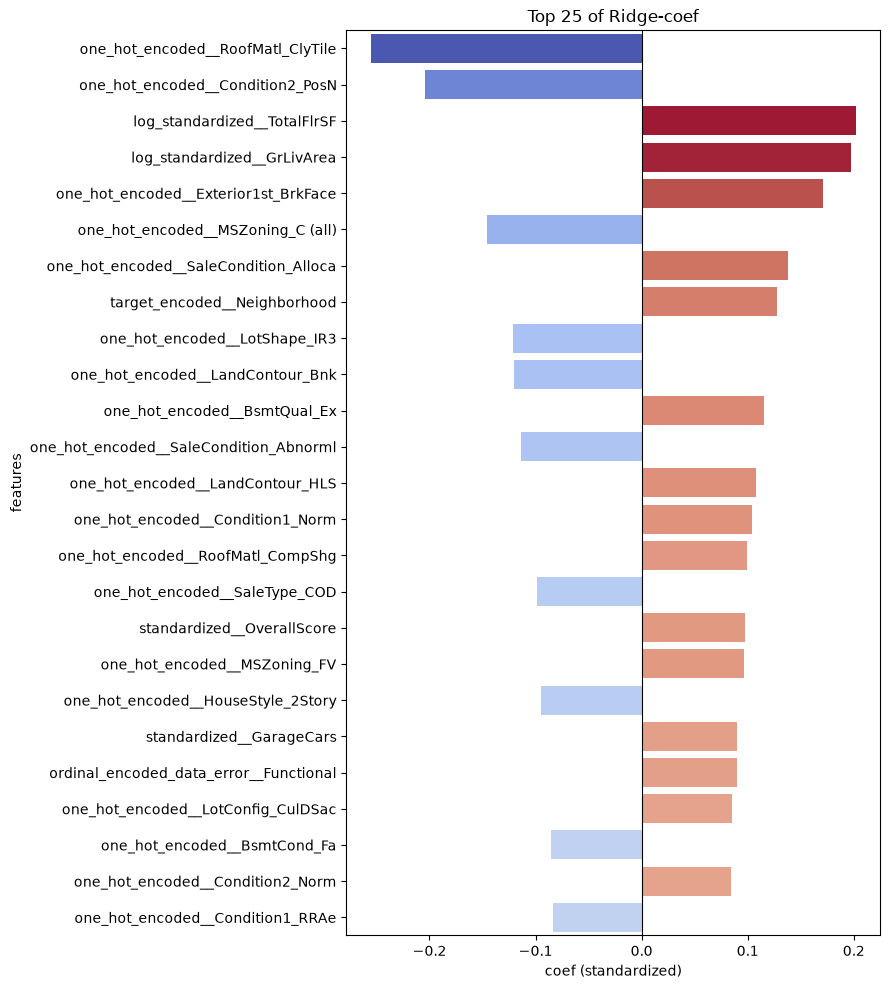

In [12]:
# 特徴量の寄与度（Ridge係数）トップ25
feature_names = model.regressor_.named_steps["prep"].get_feature_names_out()
coefs = model.regressor_.named_steps["ridge"].coef_

importance_df = pl.DataFrame({
    "feature": feature_names,
    "coef": coefs,
}).with_columns(
    pl.col("coef").abs().alias("abs_coef")
).sort("abs_coef", descending=True).head(25)

plt.figure(figsize=(9, 10))
sns.barplot(
    data=importance_df.to_pandas(),
    x="coef", y="feature",
    hue="coef", palette="coolwarm", dodge=False, legend=False,
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 25 of Ridge-coef")
plt.xlabel("coef (standardized)")
plt.ylabel("features")
plt.tight_layout()
plt.show()


### submit

In [ ]:
from sklearn.base import clone

# ベストハイパーパラメータで全学習データ(X, y)を使って最終学習
final_model = clone(model)
final_model.set_params(**grid_search.best_params_)
final_model.fit(X, y)

submit_df = pl.DataFrame({
    "Id": test['Id'],
    "SalePrice": final_model.predict(X_test)
})


In [14]:
submit_df.write_csv("../submit.csv")